# The Night of the Pilgrimage

**Thirty-four years of light over the Doñana Biosphere Reserve**

Doñana is protected because of what happens there at night: lynx, wild boar, the birds
that use the marsh as a runway between Europe and Africa. Nocturnal animals are the ones
that pay for artificial light, and Doñana is a dark island surrounded by towns that have
grown for thirty years — Almonte and its berry farms to the north, Matalascañas and
Mazagón on the coast, and El Rocío, a village of sand streets that once a year receives
a million people.

This notebook asks the two questions a light record can answer, and neither of them is
"how bright is it":

1. **How much has the night changed since 1992?** That needs the whole record, and the
   whole record is two different satellites that do not agree. `calibrate_nighttime_lights()`
   fits the conversion between them on this ROI — and most of this half of the notebook is
   spent checking whether the conversion can be believed.
2. **When does each place peak?** `get_peak_period()` maps the month of the maximum for
   every pixel. One village in Doñana answers with a date, and the two years that date is
   missing are the two years the pilgrimage was called off.

The companion notebook [Nighttime Lights (Seville)](09_nighttime_lights.ipynb) introduces the
three collections and the peak-period machinery, and deliberately does *not* join the two
records. This one joins them.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import datetime as dt

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality

# ee.Authenticate()          # only the first time
PROJECT = 'your-project-id'
ee.Initialize(project=PROJECT)
print('✓ Earth Engine initialised')

✓ Earth Engine initialised


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


The ROI is not a rectangle or a shapefile but a **DEIMS site id**: the Doñana Long-Term
Socio-ecological Research Platform, one of the eLTER sites, fetched from
[deims.org](https://deims.org/bcbc866c-3f4f-47a8-bbbc-0a93df6de7b2) by the `deims`
package (`pip install deims` if it is not already there). Anything in the eLTER network
can be swapped in by changing that string.

In [2]:
DONANA = 'deimsid/bcbc866c-3f4f-47a8-bbbc-0a93df6de7b2'

dmsp = NdviSeasonality(roi=DONANA, sat='DMSP', index='stable_lights', key='mean',
                       periods=1, start_year=1992, end_year=2013)
viirs = NdviSeasonality(roi=DONANA, sat='VIIRS', index='avg_rad', key='mean',
                        periods=1, start_year=2014, end_year=2025)

ROI = dmsp.roi
print('LTSER platform: %.0f km²' % (ROI.area(1000).getInfo() / 1e6))

There we go again...
Con Deims hemos topado, amigo Sancho...


DMSP-OLS annual nighttime lights (1992-2013, ~1km resolution)
There we go again...
Con Deims hemos topado, amigo Sancho...


VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)
  Note: VIIRS is monthly, so periods=1 averages several months per period; periods=12 keeps each month


LTSER platform: 2731 km²


`periods=1` makes each year a single composite. DMSP has one image per year and nothing
to resolve within it, and for the long series VIIRS is read the same way, so the two
records are the same kind of object: one number per pixel per year.

## 2. Two rulers for one quantity

| `sat=` | Collection | Span | Unit |
|---|---|---|---|
| `'DMSP'` | `NOAA/DMSP-OLS/NIGHTTIME_LIGHTS` | 1992-2013 | digital number, 0-63, saturating |
| `'VIIRS'` | `NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG` | 2014- | radiance, nW/cm²/sr |

Plotting one after the other draws a step at the sensor change that is pure artefact.
The records do overlap — DMSP runs to 2013, VIIRS starts in April 2012 — so the
conversion can be fitted here, on Doñana, instead of borrowed from a paper about
somewhere else.

`calibrate_nighttime_lights()` samples the overlap years pixel by pixel and fits

$$DN = 63\,(1 - e^{-a x^{b}})$$

converting **VIIRS into DMSP**, never the other way round: DMSP saturates at 63 over a
city centre, and a saturating 6-bit integer cannot be inverted into an unbounded
radiance.

In [3]:
fit = viirs.calibrate_nighttime_lights()
coef = fit['coefficients']

print('model:', coef['model'])
print('a = %.4f   b = %.4f' % (coef['a'], coef['b']))
print('r² = %.2f over %d pixels of %s' % (fit['r2'], fit['n'], fit['years']))
print('VIIRS products differ by %.1f%% over this ROI' % (100 * fit['product_difference']))

model: 63 * (1 - exp(-a * x**b))
a = 0.2993   b = 0.6585
r² = 0.63 over 2392 pixels of [2012, 2013]
VIIRS products differ by 7.6% over this ROI


An r² of 0.63 across pixels is respectable for two instruments this different, and the
last line is the first warning: the fit has to use the **uncorrected** monthly product
(`VCMCFG`), because the stray-light corrected one this library composites only starts in
2014, and over Doñana the two differ by about 8%.

## 3. What the fit never saw

The regression only accepted pixels where DMSP is above zero and below saturation. Over
Doñana that is a minority of the reserve, and it leaves the model with no information
about the dark end — where most of a protected area lives.

In [4]:
a, b = coef['a'], coef['b']
radiances = [0.05, 0.1, 0.2, 0.35, 0.5, 1, 2, 5, 10, 20, 50]
curve = pd.Series({x: 63 * (1 - np.exp(-a * x ** b)) for x in radiances},
                  name='DMSP-like DN').round(1)

dmsp_2013 = (ee.ImageCollection('NOAA/DMSP-OLS/NIGHTTIME_LIGHTS')
             .filterDate('2013-01-01', '2014-01-01').select('stable_lights').mean())
dark = dmsp_2013.eq(0).reduceRegion(ee.Reducer.mean(), ROI, 1000,
                                    maxPixels=1e9).getInfo()['stable_lights']

print(curve.to_frame().T.to_string())
print('\nshare of the reserve DMSP records as exactly 0 in 2013: %.0f%%' % (100 * dark))

              0.05   0.10   0.20   0.35   0.50   1.00   2.00   5.00   10.00  20.00  50.00
DMSP-like DN    2.6    4.0    6.2    8.8   10.9   16.3   23.7   36.4   46.9   55.7   61.8

share of the reserve DMSP records as exactly 0 in 2013: 51%


Half of Doñana is *zero* on the DMSP scale, and the fitted curve cannot produce a zero:
a pixel at 0.35 nW/cm²/sr — which is what the marsh reads on a moonless night, with no
lamp within ten kilometres — comes out as **DN 8**, the value of a small town.

The reason is not a bug in the fit but what the fit was shown. The pairs it learned from
include DMSP's halo: that sensor smears a town's light over the neighbouring kilometres,
so a dark pixel next to Almonte reads DN 10 while VIIRS, which barely smears at all,
reads a few tenths. The regression has no way to tell that halo from real light, and it
concludes that a few tenths of a nW means DN 8.

Applied as it comes, the conversion therefore lights up the entire reserve. That is
worth seeing rather than taking on trust.

In [5]:
GRID = ee.Image(ee.ImageCollection('NOAA/DMSP-OLS/NIGHTTIME_LIGHTS').first()).projection()
VCOL = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
VPROJ = ee.Image(VCOL.first()).projection()
AREA = ee.Image.pixelArea().divide(1e6)
LIT = 5          # DN at which a village stops being background
STATS = ee.Reducer.mean().combine(ee.Reducer.sum(), sharedInputs=True)


def on_dmsp_grid(radiance):
    """VIIRS is finer than DMSP, so it is averaged onto the DMSP grid first."""
    return (radiance.setDefaultProjection(VPROJ)
            .reduceResolution(ee.Reducer.mean(), maxPixels=1024)
            .reproject(GRID))


def summarise(dn):
    """Mean DN over the reserve, and how many km² are lit."""
    lit = dn.gte(LIT).selfMask().multiply(AREA).rename('lit')
    return dn.rename('dn').addBands(lit).reduceRegion(STATS, ROI, 1000, maxPixels=1e9)


raw_2014 = ee.Image(viirs.get_year_composite().first()).select(0)
naive = viirs.to_dmsp_like(on_dmsp_grid(raw_2014), coef, band=0)

print(pd.Series(summarise(naive).getInfo()).round(1).to_string())
print('\nthe reserve is %.0f km² in total' % (ROI.area(1000).getInfo() / 1e6))

Year 2014: 1/1 periods with data using avg_rad index


Year 2015: 1/1 periods with data using avg_rad index


Year 2016: 1/1 periods with data using avg_rad index


Year 2017: 1/1 periods with data using avg_rad index


Year 2018: 1/1 periods with data using avg_rad index


...

Year 2023: 1/1 periods with data using avg_rad index


Year 2024: 1/1 periods with data using avg_rad index


Year 2025: 1/1 periods with data using avg_rad index


dn_mean        12.0
dn_sum      40683.2
lit_mean        0.8
lit_sum      2731.9



the reserve is 2731 km² in total


2 732 km² lit out of 2 732: every pixel of Doñana, dunes and marsh included, converted
into a town. The number to fix is the **background**.

## 4. The background, and the fact that it moves

DMSP's `stable_lights` band has already had its background identified and replaced with
zeros. VIIRS has not: its dark areas sit at a small positive radiance made of detector
noise, airglow and scattered light. Subtracting it is the missing step — and it cannot
be a single constant, because it drifts.

The level is measured where there is certainly nothing to light: a box of open Atlantic
fifteen kilometres offshore, outside the ROI, read from the collection rather than from
the clipped composite.

In [6]:
SEA = ee.Geometry.Rectangle([-6.85, 36.60, -6.55, 36.75])   # open water, no lights


def background(year, collection=VCOL):
    """That year's dark-sky level, in nW/cm²/sr."""
    radiance = (collection.filterDate(f'{year}-01-01', f'{year + 1}-01-01')
                .select('avg_rad').mean())
    return ee.Number(radiance.reduceRegion(ee.Reducer.median(), SEA, 500,
                                           maxPixels=1e9).get('avg_rad'))


levels = ee.Dictionary({str(y): background(y) for y in range(2014, 2026)}).getInfo()
levels = pd.Series({int(y): v for y, v in levels.items()}).sort_index()
print(levels.round(3).to_string())

2014    0.164
2015    0.129
2016    0.107
2017    0.287
2018    0.277
2019    0.264
2020    0.351
2021    0.392
2022    0.390
2023    0.430
2024    0.443
2025    0.418


The dark sea "brightens" from 0.16 to 0.44 nW/cm²/sr in eleven years — nearly a tripling
of a quantity that should not change, over water where nothing was built. Some of it may
be real skyglow drifting out from the coast; most of it is the instrument and the
processing. Either way it is not Doñana, and an analysis that skips this step measures
the drift and calls it growth: the naive series above rises by a third between 2014 and
2025 in exactly the places where nothing happens.

Subtracting each year's own level fixes both problems at once — the dark end returns to
zero, and the drift leaves with it.

In [7]:
def to_dmsp_like(radiance, year, collection=VCOL):
    """Background-corrected VIIRS radiance, converted to DMSP-like DN."""
    clean = radiance.subtract(ee.Image.constant(background(year, collection))).max(0)
    return viirs.to_dmsp_like(on_dmsp_grid(clean), coef, band=0)


corrected = to_dmsp_like(raw_2014, 2014)
print(pd.Series(summarise(corrected).getInfo()).round(1).to_string())

dn_mean         9.2
dn_sum      31223.0
lit_mean        0.8
lit_sum      1479.8


## 5. Does the join hold? The overlap decides

The only honest test is the one place both sensors exist: 2012 and 2013. If the
conversion works, the converted VIIRS of those years should reproduce the DMSP of those
years — not approximately in shape, but in the numbers being read off the series.

This is the same data the coefficients were fitted on, so it measures the model's
consistency, not its ability to predict an unseen year. It is still the tightest
available check, and it is the one that fails loudly when the background is left in.

In [8]:
VCMCFG = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG')   # the fitted product
DMSP = ee.ImageCollection('NOAA/DMSP-OLS/NIGHTTIME_LIGHTS')

rows = []
for year in (2012, 2013):
    measured = (DMSP.filterDate(f'{year}-01-01', f'{year + 1}-01-01')
                .select('stable_lights').mean().setDefaultProjection(GRID))
    radiance = (VCMCFG.filterDate(f'{year}-01-01', f'{year + 1}-01-01')
                .select('avg_rad').mean())
    converted = to_dmsp_like(radiance, year, collection=VCMCFG)

    for label, image in [('DMSP, measured', measured),
                         ('VIIRS, converted', converted)]:
        values = summarise(image).getInfo()
        rows.append({'year': year, 'source': label,
                     'mean DN': values['dn_mean'], 'lit km²': values['lit_sum']})

overlap = pd.DataFrame(rows).set_index(['year', 'source'])
overlap.round(1)

mean DN  lit km²
year source                            
2012 DMSP, measured        8.1   1280.9
     VIIRS, converted      8.4   1300.1
2013 DMSP, measured        8.0   1317.0
     VIIRS, converted      8.3   1286.7

Three per cent apart in mean brightness and two per cent in lit area. The conversion can
carry the series across the seam — with two caveats that do not go away:

- **DMSP itself is not calibrated over time.** It was flown by a succession of satellites
  whose digital numbers were never tied to each other, and the published series apply an
  intercalibration before reading any trend. This notebook does not, so the DMSP half
  carries the instruments' drift inside it. The 2010 spike below is a satellite change,
  not a building boom.
- **The coefficients were fitted on `VCMCFG` and are applied to `VCMSLCFG`**, which
  differ by about 8% here. That is the size of the uncertainty at the seam, and any step
  smaller than it means nothing.

## 6. Thirty-four years, one series

In [9]:
old_composites = dmsp.get_year_composite()      # 1992-2013, one band per year
new_composites = viirs.get_year_composite()     # 2014-2025, the same shape


def yearly_stats(collection, years, convert=False):
    """Mean DN and lit area for each year, in a single request."""
    images = collection.toList(collection.size())
    features = []
    for i, year in enumerate(years):
        image = ee.Image(images.get(i)).select(0)
        if convert:
            image = to_dmsp_like(image, year)
        features.append(ee.Feature(None, {'year': year}).set(summarise(image)))
    rows = ee.FeatureCollection(features).getInfo()['features']
    return pd.DataFrame([f['properties'] for f in rows])


old = yearly_stats(old_composites, range(1992, 2014))
new = yearly_stats(new_composites, range(2014, 2026), convert=True)

series = pd.concat([old.assign(sensor='DMSP'), new.assign(sensor='VIIRS')])
series = series.set_index('year').rename(columns={'dn_mean': 'mean DN',
                                                  'lit_sum': 'lit km²'})
series[['mean DN', 'lit km²', 'sensor']].round(2).T

Year 1992: 1/1 periods with data using stable_lights index


Year 1993: 1/1 periods with data using stable_lights index


Year 1994: 1/1 periods with data using stable_lights index


Year 1995: 1/1 periods with data using stable_lights index


Year 1996: 1/1 periods with data using stable_lights index


...

Year 2022: 1/1 periods with data using avg_rad index


Year 2023: 1/1 periods with data using avg_rad index


Year 2024: 1/1 periods with data using avg_rad index


Year 2025: 1/1 periods with data using avg_rad index


year,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
mean DN,5.43,5.67,5.68,6.69,6.29,5.73,6.7,6.86,7.09,7.03,...,9.39,9.63,9.53,9.79,9.53,10.07,10.08,10.39,10.46,10.64
lit km²,1253.74,935.45,934.36,1121.9,1096.29,910.35,974.68,1061.52,1108.25,1071.89,...,1549.41,1577.39,1556.94,1609.85,1552.63,1634.91,1634.11,1737.44,1778.81,1787.75
sensor,DMSP,DMSP,DMSP,DMSP,DMSP,DMSP,DMSP,DMSP,DMSP,DMSP,...,VIIRS,VIIRS,VIIRS,VIIRS,VIIRS,VIIRS,VIIRS,VIIRS,VIIRS,VIIRS


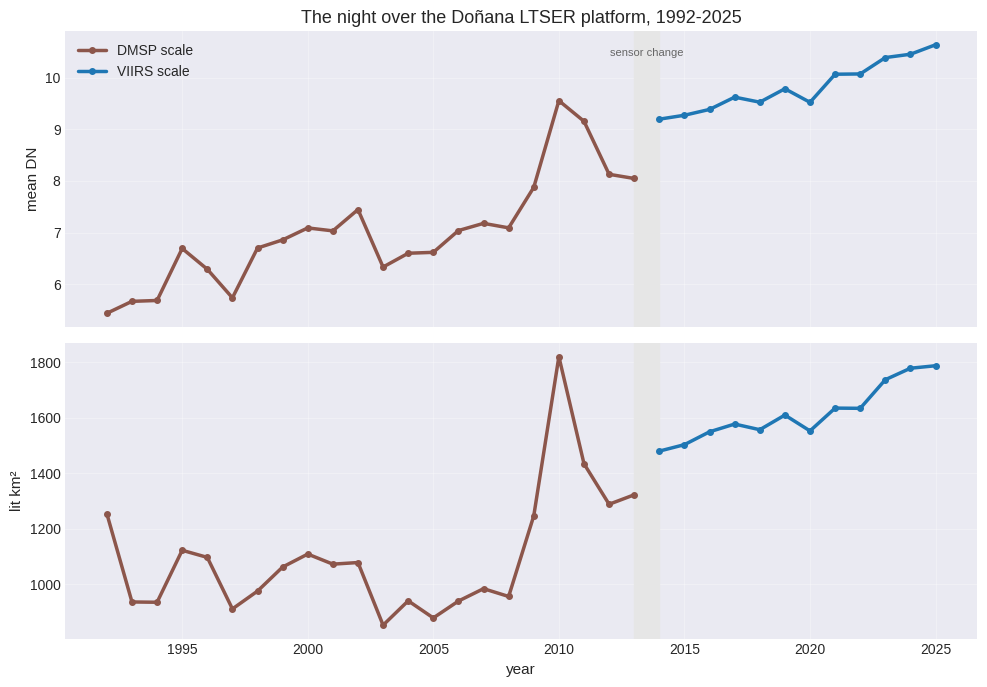

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
colours = {'DMSP': '#8c564b', 'VIIRS': '#1f77b4'}

for ax, column in zip(axes, ['mean DN', 'lit km²']):
    for sensor, part in series.groupby('sensor', sort=False):
        ax.plot(part.index, part[column], 'o-', ms=4, color=colours[sensor],
                label=f'{sensor} scale')
    ax.axvspan(2013, 2014, color='0.9')
    ax.set_ylabel(column)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

axes[0].text(2013.5, axes[0].get_ylim()[1] * 0.97, 'sensor change', ha='center',
             fontsize=8, color='0.4', va='top')
axes[0].legend(frameon=False, loc='upper left')
axes[0].set_title('The night over the Doñana LTSER platform, 1992-2025')
axes[1].set_xlabel('year')
plt.tight_layout()

Read the line, not the individual years. The mean brightness of the reserve roughly
**doubles** across the record, and the lit area grows by about half, with the fastest
climb in the 2000s — the building years of the Andalusian coast — and a slower, steady
rise since.

The wobbles inside the DMSP half are the instruments talking: 2010 and 2011 stand a
digital number above their neighbours because a new satellite took over, and the dip at
2003 is another changeover. This is exactly what intercalibrating the DMSP series is for,
and why the trend here is read as a slope over two decades rather than a difference
between two years.

The seam is still visible, and it should be: 8.0 in 2013 against 9.2 in 2014, a step of
14% where the overlap check promised 3%. About 8 points of that are the change of VIIRS
product, measured at the start; the rest is whatever the conversion cannot carry — and it
is the reason nothing in this notebook is concluded from a pair of years straddling 2013.
A thirty-year slope survives a 14% seam. A comparison of 2013 with 2014 does not.

## 7. Where the light arrived

The series says the reserve got brighter. The maps say where, and the boundary of the
National Park — the strictly protected core — is drawn on top of them, from the World
Database on Protected Areas.

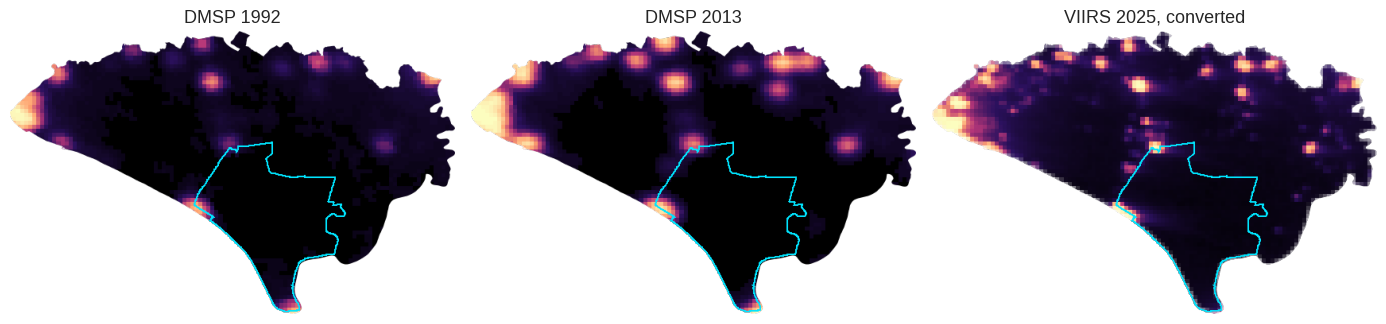

In [11]:
PARK = (ee.FeatureCollection('WCMC/WDPA/current/polygons')
        .filterBounds(ROI)
        .filter(ee.Filter.And(ee.Filter.eq('NAME', 'Doñana'),
                              ee.Filter.eq('DESIG_ENG', 'Nacional Park')))
        .geometry())
outline = ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(PARK)]), 1, 2).selfMask()

VIS = {'min': 0, 'max': 63, 'palette': ['000000', '2c115f', 'b63679', 'fe9f6d', 'fcfdbf']}


def thumbnail(image, region, dimensions=560):
    picture = image.visualize(**VIS).blend(outline.visualize(palette=['00e5ff']))
    url = picture.getThumbURL({'region': region, 'dimensions': dimensions,
                               'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))


def dmsp_year(year):
    return (DMSP.filterDate(f'{year}-01-01', f'{year + 1}-01-01')
            .select('stable_lights').mean().clip(ROI))


panels = [(dmsp_year(1992), 'DMSP 1992'),
          (dmsp_year(2013), 'DMSP 2013'),
          (to_dmsp_like(ee.Image(new_composites.toList(12).get(11)).select(0),
                        2025).clip(ROI), 'VIIRS 2025, converted')]

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2))
for ax, (image, title) in zip(axes, panels):
    ax.imshow(thumbnail(image, ROI))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()

The towns thicken and join up: Almonte and Bollullos to the north spread into the berry
farms around them, Matalascañas and Mazagón grow along the coast, and the dark wedge in
the middle — the marsh and the dunes, inside the cyan boundary — stays dark.

Stays dark, but not equally dark.

National Park, mean DN: 1992 1.8 → 2013 2.4 | 2014 4.0 → 2025 5.3


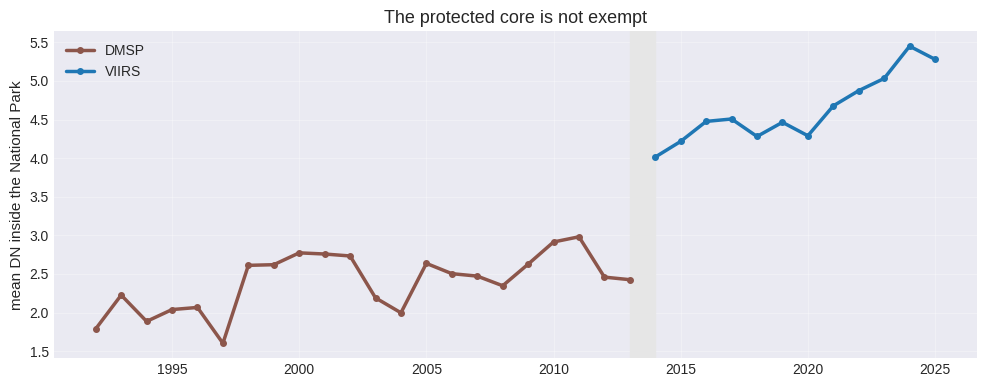

In [12]:
def park_series(collection, years, convert=False):
    images = collection.toList(collection.size())
    features = []
    for i, year in enumerate(years):
        image = ee.Image(images.get(i)).select(0)
        if convert:
            image = to_dmsp_like(image, year)
        features.append(ee.Feature(None, {'year': year}).set(
            image.rename('dn').reduceRegion(ee.Reducer.mean(), PARK, 1000,
                                            maxPixels=1e9)))
    rows = ee.FeatureCollection(features).getInfo()['features']
    return pd.DataFrame([f['properties'] for f in rows]).set_index('year')['dn']


core = pd.concat([park_series(old_composites, range(1992, 2014)),
                  park_series(new_composites, range(2014, 2026), convert=True)])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(core.index[:22], core.values[:22], 'o-', ms=4, color='#8c564b', label='DMSP')
ax.plot(core.index[22:], core.values[22:], 'o-', ms=4, color='#1f77b4', label='VIIRS')
ax.axvspan(2013, 2014, color='0.9')
ax.set_ylabel('mean DN inside the National Park')
ax.set_title('The protected core is not exempt')
ax.legend(frameon=False)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

print('National Park, mean DN: 1992 %.1f → 2013 %.1f | 2014 %.1f → 2025 %.1f'
      % (core[1992], core[2013], core[2014], core[2025]))

Inside the park boundary there are almost no lamps. What the sensor sees there is the
glow of everywhere else — scattered light over the marsh, plus DMSP's halo in the first
half — and it grows faster than the reserve as a whole: **+31% between 2014 and 2025**
against +16% for the whole platform, on the VIIRS half alone, where the comparison is
between like and like.

That is the measurement that matters ecologically. Nobody built anything in the core; the
core got brighter anyway.

## 8. When, not how much

The second question needs months instead of years. Same collection, same ROI,
`periods=12`, and `get_peak_period()` asks each pixel which month holds its maximum —
the machinery [notebook 09](09_nighttime_lights.ipynb) introduces.

In [13]:
monthly = NdviSeasonality(roi=DONANA, sat='VIIRS', index='avg_rad', key='mean',
                          periods=12, start_year=2014, end_year=2025)

peak = monthly.get_peak_period(mask_below=2, return_peak_value=True, return_ties=True)
peak.bandNames().getInfo()

There we go again...
Con Deims hemos topado, amigo Sancho...


VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)


Year 2014: 12/12 periods with data using avg_rad index


Year 2015: 12/12 periods with data using avg_rad index


Year 2016: 12/12 periods with data using avg_rad index


...

Year 2022: 12/12 periods with data using avg_rad index


Year 2023: 12/12 periods with data using avg_rad index


Year 2024: 12/12 periods with data using avg_rad index


Year 2025: 12/12 periods with data using avg_rad index


['peak_period', 'peak_value', 'ties']

`mask_below=2` throws away the pixels whose brightest month never reaches 2 nW/cm²/sr:
the month of maximum of an unlit dune is the month its noise happened to be highest.

A single map of peak months would be hard to read over an area that is mostly dark, so
the question is asked of the places where people live — four of them, each a different
kind of night.

In [14]:
TOWNS = {'El Rocío': (-6.4871, 37.1323),          # the pilgrimage village
         'Matalascañas': (-6.5522, 36.9906),      # beach resort, summer population
         'Almonte': (-6.5163, 37.2615),           # the county town, lived in all year
         'Mazagón': (-6.8352, 37.1318)}           # coast again, smaller

places = {name: ee.Geometry.Point(*coords).buffer(900)
          for name, coords in TOWNS.items()}

towns = {name: NdviSeasonality(roi=geometry, sat='VIIRS', index='avg_rad', key='mean',
                               periods=12, start_year=2014, end_year=2025)
         for name, geometry in places.items()}
composites = {name: instance.get_year_composite()       # kept, they are used again below
              for name, instance in towns.items()}

profiles = {}
for name, instance in towns.items():
    typical = composites[name].median()                 # the typical year, month by month
    values = typical.reduceRegion(ee.Reducer.mean(), places[name], 500,
                                  maxPixels=1e9).getInfo()
    profiles[name] = [values[month] for month in instance.period_names]

MONTHS = [month[:3].title() for month in towns['El Rocío'].period_names]
profiles = pd.DataFrame(profiles, index=MONTHS)
(profiles / profiles.mean()).round(2)

There we go again...
VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)
There we go again...
VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)
There we go again...
VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)
There we go again...
VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)


Year 2014: 12/12 periods with data using avg_rad index


Year 2015: 12/12 periods with data using avg_rad index


Year 2016: 12/12 periods with data using avg_rad index


Year 2017: 12/12 periods with data using avg_rad index


...

Year 2022: 12/12 periods with data using avg_rad index


Year 2023: 12/12 periods with data using avg_rad index


Year 2024: 12/12 periods with data using avg_rad index


Year 2025: 12/12 periods with data using avg_rad index


,El Rocío,Matalascañas,Almonte,Mazagón
Jan,0.92,0.94,0.95,1.01
Feb,0.91,0.98,0.99,1.00
Mar,0.87,1.01,1.00,0.98
Apr,0.90,1.05,0.98,0.98
May,1.22,1.03,1.05,1.01
Jun,1.29,1.04,1.04,1.06
Jul,1.05,1.07,1.09,1.03
Aug,1.10,1.06,1.03,1.04
Sep,1.00,0.98,0.99,0.98
Oct,0.93,0.95,0.91,0.98


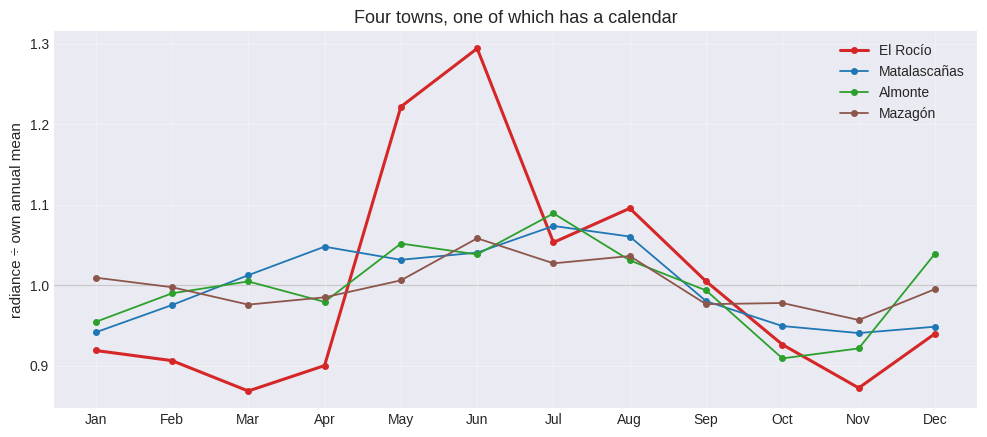

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
relative = profiles / profiles.mean()
styles = {'El Rocío': ('#d62728', 2.2), 'Matalascañas': ('#1f77b4', 1.3),
          'Almonte': ('#2ca02c', 1.3), 'Mazagón': ('#8c564b', 1.3)}

for name in profiles.columns:
    colour, width = styles[name]
    ax.plot(relative.index, relative[name], 'o-', ms=4, lw=width, color=colour,
            label=name)

ax.axhline(1, color='0.7', lw=0.8, zorder=0)
ax.set_ylabel('radiance ÷ own annual mean')
ax.set_title('Four towns, one of which has a calendar')
ax.legend(frameon=False)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

Three flat lines and a spike.

Matalascañas empties in winter and fills in August, and its curve moves by seven per
cent: street lighting is on whether or not anybody is there, and a beach town's lamps
burn in February for nobody. Almonte and Mazagón are flatter still. Seasonal population
is nearly invisible from orbit, which is worth remembering before reading any nighttime
lights map as a map of people.

El Rocío peaks **twenty to thirty per cent above its own average in May and June**, and
El Rocío is a village of some 1 500 residents whose streets are sand. What happens there
in May or June is the Romería: at Pentecost, around a million pilgrims converge on the
village, camp around it and walk it all night.

Pentecost is a moveable feast, which is why the spike is spread over two months instead
of standing in one. That is also the test.

## 9. The years the pilgrimage did not happen

`get_peak_period(per_year=True)` gives one peak month per year instead of a single
typical answer, and `get_peak_statistics()` summarises those years the way a circular
variable has to be summarised — months wrap around, so an ordinary average of December
and January lands in June.

In [16]:
rocio = towns['El Rocío']

peaks = rocio.get_peak_period(per_year=True, mask_below=2)
stats = rocio.get_peak_statistics(peaks=peaks, min_years=6)

summary = stats.reduceRegion(ee.Reducer.mean(), places['El Rocío'], 500,
                             maxPixels=1e9).getInfo()
print('El Rocío: circular mean %.1f (month), concentration R = %.2f, over %.0f years'
      % (summary['circular_mean'], summary['concentration'], summary['n_years']))

for name, instance in towns.items():
    values = instance.get_peak_statistics(mask_below=2, min_years=6).reduceRegion(
        ee.Reducer.mean(), places[name], 500, maxPixels=1e9).getInfo()
    print('%-14s mean month %.1f   R = %.2f' % (name, values['circular_mean'],
                                                values['concentration']))

Year 2014: 12/12 periods with data using avg_rad index


Year 2015: 12/12 periods with data using avg_rad index
Year 2016: 12/12 periods with data using avg_rad index


Year 2017: 12/12 periods with data using avg_rad index


Year 2018: 12/12 periods with data using avg_rad index


Year 2019: 12/12 periods with data using avg_rad index


...

Year 2021: 12/12 periods with data using avg_rad index


Year 2022: 12/12 periods with data using avg_rad index
Year 2023: 12/12 periods with data using avg_rad index


Year 2024: 12/12 periods with data using avg_rad index


Year 2025: 12/12 periods with data using avg_rad index


Mazagón        mean month 6.6   R = 0.35


R is the concentration: 1 means every year peaked at the same time, 0 means the years
point in every direction and the mean month is an artefact of averaging. El Rocío is the
only one of the four whose years agree with each other, and its mean sits in late May.

The years themselves are better than the summary, because two of them are an experiment
nobody would have been allowed to run: **the Romería was cancelled in 2020 and 2021**.

In [17]:
# Pentecost Sunday, the weekend the pilgrimage arrives
PENTECOST = {2014: 6, 2015: 5, 2016: 5, 2017: 6, 2018: 5, 2019: 6,
             2020: 5, 2021: 5, 2022: 6, 2023: 5, 2024: 5, 2025: 6}
CANCELLED = (2020, 2021)

months_of = composites['El Rocío'].toList(12)
features = [ee.Feature(None, {'year': year}).set(
                ee.Image(months_of.get(i)).reduceRegion(
                    ee.Reducer.mean(), places['El Rocío'], 500, maxPixels=1e9))
            for i, year in enumerate(range(2014, 2026))]
months = pd.DataFrame([f['properties'] for f in
                       ee.FeatureCollection(features).getInfo()['features']])
months = months.set_index('year')[rocio.period_names]

rest = [m for m in rocio.period_names if m not in ('may', 'june')]
pilgrimage = pd.DataFrame({
    'month of Pentecost': [rocio.period_names[PENTECOST[y] - 1][:3].title()
                           for y in months.index],
    'that month': [months.loc[y, rocio.period_names[PENTECOST[y] - 1]]
                   for y in months.index],
    'rest of the year': months[rest].mean(axis=1),
}, index=months.index)
pilgrimage['excess'] = pilgrimage['that month'] / pilgrimage['rest of the year'] - 1
pilgrimage.style.format({'that month': '{:.1f}', 'rest of the year': '{:.1f}',
                         'excess': '{:+.0%}'})

,month of Pentecost,that month,rest of the year,excess
year,,,,
2014,Jun,42.7,27.0,+58%
2015,May,40.0,26.2,+53%
2016,May,40.2,24.5,+64%
2017,Jun,37.4,25.1,+49%
2018,May,37.4,23.8,+57%
2019,Jun,42.4,25.3,+67%
2020,May,20.4,20.3,+0%
2021,May,24.2,21.5,+12%
2022,Jun,50.4,24.6,+105%


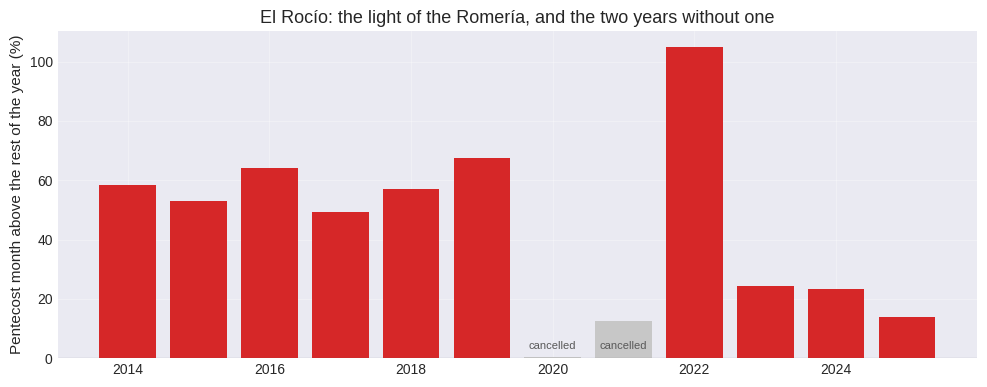

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
colours = ['#c7c7c7' if year in CANCELLED else '#d62728' for year in pilgrimage.index]
ax.bar(pilgrimage.index, 100 * pilgrimage['excess'], color=colours)
ax.axhline(0, color='0.4', lw=0.8)
ax.set_ylabel('Pentecost month above the rest of the year (%)')
ax.set_title('El Rocío: the light of the Romería, and the two years without one')
for year in CANCELLED:
    ax.annotate('cancelled', (year, 3), ha='center', fontsize=8, color='0.35')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

Every year with a pilgrimage runs between +14% and +105% above the village's own
baseline. **2020, the year the Romería was called off, reads exactly 0%**, and 2021, when
it was called off again and the Virgin stayed inside, reads +12% — the lowest of the
record after 2020.

The signal is not a satellite artefact, a season, or a better month for clear skies: it
is a million people and their lights, removed for two years and returned in 2022, when
the excess is the largest of the whole series.

The falling excess from 2023 onwards is the *baseline* rising, not the pilgrimage
fading: El Rocío's ordinary nights go from about 25 to about 35 nW/cm²/sr in the last
three years. Something changed in how the village is lit, and this record cannot say
what — only that it happened.

## 10. The exact night

Monthly composites can only place the pilgrimage in a month. The daily Black Marble
product (`VIIRS_DAILY`, `NASA/VIIRS/002/VNP46A2`) models away moonlight, atmosphere and
viewing angle, so one night can be compared with the next, and `periods=365` splits the
year into single nights.

In [19]:
# the village and the fields it camps in, not the sand streets alone
ROCIO = ee.Geometry.Point(*TOWNS['El Rocío']).buffer(1500)

# Pentecost Sunday; the brotherhoods arrive over the days before and the Virgin
# comes out in the small hours of the Monday
WHITSUN = {2019: dt.date(2019, 6, 9), 2022: dt.date(2022, 6, 5),
           2024: dt.date(2024, 5, 19)}


def brightest_nights(year, top=4):
    """The nights that hold the maximum for the most pixels of El Rocío."""
    daily = NdviSeasonality(roi=ROCIO, sat='VIIRS_DAILY', index='ntl', key='mean',
                            periods=365, start_year=year, end_year=year)
    night = daily.get_peak_period(mask_below=5)
    counts = night.select('peak_period').reduceRegion(
        ee.Reducer.frequencyHistogram(), ROCIO, 500,
        maxPixels=1e9).getInfo()['peak_period']

    january = dt.date(year, 1, 1)
    rows = sorted(((int(float(day)), n) for day, n in counts.items()),
                  key=lambda row: -row[1])[:top]
    return pd.DataFrame([{'year': year,
                          'night': january + dt.timedelta(days=day - 1),
                          'pixels': round(n)} for day, n in rows])


nights = pd.concat([brightest_nights(year) for year in WHITSUN])
nights['days from Whitsun'] = [(row.night - WHITSUN[row.year]).days
                               for row in nights.itertuples()]
nights.set_index(['year', 'night'])

There we go again...
VIIRS Black Marble daily nighttime lights (2012-present, ~500m resolution)
Applying pixel-level quality mask using Mandatory_Quality_Flag


Year 2019: 365/365 periods with data using ntl index


There we go again...
VIIRS Black Marble daily nighttime lights (2012-present, ~500m resolution)
Applying pixel-level quality mask using Mandatory_Quality_Flag


No data for period 208 (p208) in year 2022, filled with a masked band
No data for period 209 (p209) in year 2022, filled with a masked band
No data for period 210 (p210) in year 2022, filled with a masked band
No data for period 211 (p211) in year 2022, filled with a masked band
No data for period 212 (p212) in year 2022, filled with a masked band
No data for period 213 (p213) in year 2022, filled with a masked band
No data for period 214 (p214) in year 2022, filled with a masked band
No data for period 215 (p215) in year 2022, filled with a masked band
No data for period 216 (p216) in year 2022, filled with a masked band
No data for period 217 (p217) in year 2022, filled with a masked band
No data for period 218 (p218) in year 2022, filled with a masked band
No data for period 219 (p219) in year 2022, filled with a masked band
No data for period 220 (p220) in year 2022, filled with a masked band
No data for period 221 (p221) in year 2022, filled with a masked band
No data for period 2

Year 2022: 350/365 periods with data using ntl index


There we go again...
VIIRS Black Marble daily nighttime lights (2012-present, ~500m resolution)
Applying pixel-level quality mask using Mandatory_Quality_Flag


No data for period 150 (p150) in year 2024, filled with a masked band
No data for period 151 (p151) in year 2024, filled with a masked band
No data for period 152 (p152) in year 2024, filled with a masked band
No data for period 153 (p153) in year 2024, filled with a masked band
No data for period 154 (p154) in year 2024, filled with a masked band
No data for period 191 (p191) in year 2024, filled with a masked band
No data for period 192 (p192) in year 2024, filled with a masked band
No data for period 193 (p193) in year 2024, filled with a masked band
No data for period 194 (p194) in year 2024, filled with a masked band
No data for period 195 (p195) in year 2024, filled with a masked band
No data for period 196 (p196) in year 2024, filled with a masked band
No data for period 206 (p206) in year 2024, filled with a masked band
No data for period 207 (p207) in year 2024, filled with a masked band
No data for period 208 (p208) in year 2024, filled with a masked band
No data for period 2

No data for period 307 (p307) in year 2024, filled with a masked band
No data for period 308 (p308) in year 2024, filled with a masked band
No data for period 309 (p309) in year 2024, filled with a masked band
Year 2024: 346/365 periods with data using ntl index


pixels  days from Whitsun
year night                                
2019 2019-06-10      12                  1
     2019-06-09       5                  0
     2019-06-16       5                  7
     2019-06-11       2                  2
2022 2022-06-06       6                  1
     2022-06-07       4                  2
     2022-12-17       4                195
     2022-05-28       2                 -8
2024 2024-05-16       9                 -3
     2024-04-04       3                -45
     2024-01-26       3               -114
     2024-01-14       2               -126

The last column is the whole result. In **2019** the brightest night of the year is 10
June, Pentecost Monday — the night the Virgin is carried out of the hermitage and the
village does not sleep — with 9, 11 and 16 June behind it. In **2022** it is 6 June,
Pentecost Monday again. In **2024** it is 16 May, the Thursday before, when the
brotherhoods arrive and the camp around the village fills.

Out of 365 candidate nights, with no dates given to the algorithm, the answer lands in
the pilgrimage week three times out of three. The runners-up outside that week — a night
in December, a couple in January — are Christmas lighting and single-pixel noise, and the
pixel counts are small because El Rocío is small: that is why the count is reported next
to the date instead of a bare ranking.

## 11. What to take away

**A conversion between records has to be checked where they overlap.** Fitting
coefficients takes one line; the r² of that fit says how well two images agree over
space, and nothing about whether a series can cross the seam. The overlap years answer
that, in the units the series is actually read in — here, 3% in mean brightness and 2% in
lit area, against a naive version that lit up the whole reserve.

**Subtract the background, and measure it every year.** VIIRS dark areas are not zero,
and their level tripled between 2014 and 2025 over open ocean. Any trend computed without
that subtraction is partly the instrument's, and over a protected area — where there is
little real light to swamp it — it is mostly the instrument's.

**A protected core is lit by everywhere else.** No lamps were installed inside the
National Park, and its mean brightness still grew faster than the region around it.
Light is the pollutant that does not respect a boundary.

**Seasonal population is nearly invisible; events are not.** A beach town that triples
its inhabitants in August moves by 7%, because street lighting does not know whether
anyone is home. A pilgrimage that camps in a field for a week moves by 50%.

**The best validation is the one you did not have to design.** Two cancelled Romerías
turn a plausible spike into a measurement.